gapminder.tsv 파일 데이터 분석

# 필요한 모듈 임포트

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


*   파일을 읽고 DataFrame 생성
*   국가 수
*   대륙 수
*   연도 수
*   기대수명 분석
    *   기대수명 최댓값, 최솟값 행
*   1인당 GDP 분석
    *   1인당 GDP 최댓값, 최솟값 행
*   인구수 분석
*   그룹별 통계량


In [2]:
file_path = "https://raw.githubusercontent.com/JakeOh/202511_BD53/refs/heads/main/datasets/gapminder.tsv"

gapminder = pd.read_csv(file_path, sep="\t")

gapminder.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


In [3]:
gapminder.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 80.0+ KB


In [4]:
# 국가 수
len(gapminder["country"].unique())

142

In [5]:
# 대륙 수
gapminder["continent"].value_counts()

,count
continent,
Africa,624
Asia,396
Europe,360
Americas,300
Oceania,24


In [6]:
continents = gapminder.continent.unique()
continents.size

5

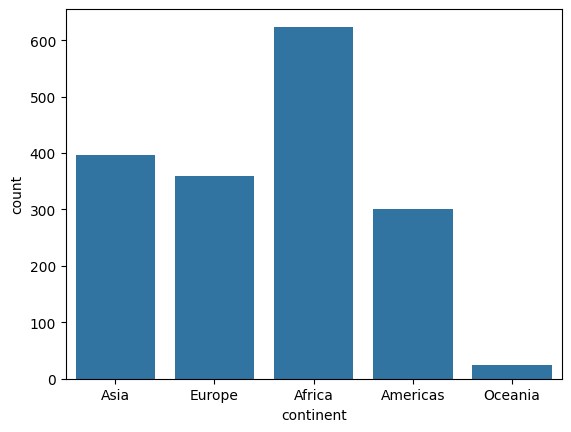

In [7]:
sns.countplot(data=gapminder, x="continent")

plt.show()

In [8]:
# 연도 수
len(gapminder["year"].value_counts().index)

12

In [9]:
gapminder["year"].value_counts()

,count
year,
1952,142
1957,142
1962,142
1967,142
1972,142
1977,142
1982,142
1987,142
1992,142


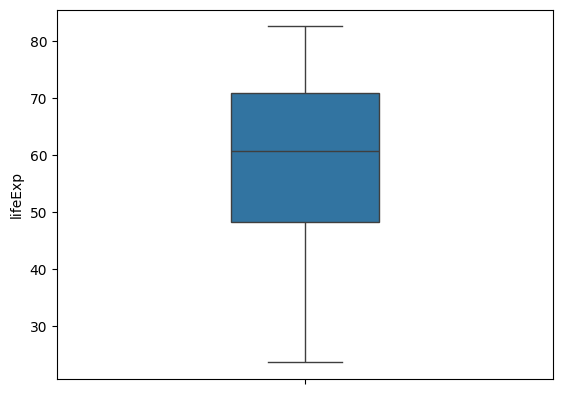

In [10]:
# 기대수명 분석
sns.boxplot(data=gapminder, y="lifeExp", width=0.3)

plt.show()

In [11]:
gapminder.lifeExp.describe()

,lifeExp
count,1704.000000
mean,59.474439
std,12.917107
min,23.599000
25%,48.198000
50%,60.712500
75%,70.845500
max,82.603000


In [12]:
# 기대수명 최댓값 행
gapminder[gapminder.lifeExp == gapminder.lifeExp.max()]

,country,continent,year,lifeExp,pop,gdpPercap
803,Japan,Asia,2007,82.603,127467972,31656.06806


In [13]:
# 기대수명 최솟값 행
gapminder[gapminder.lifeExp == gapminder.lifeExp.min()]

,country,continent,year,lifeExp,pop,gdpPercap
1292,Rwanda,Africa,1992,23.599,7290203,737.068595


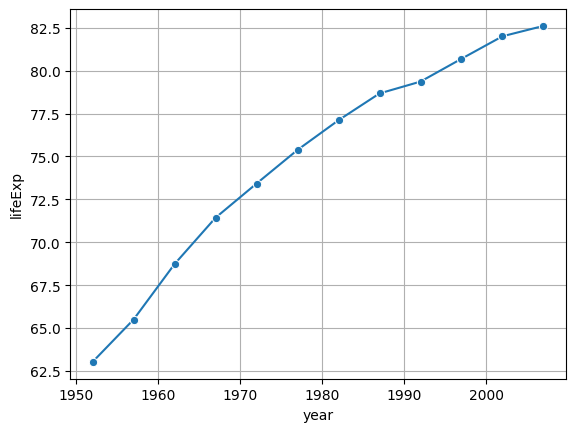

In [14]:
japan_df = gapminder[gapminder.country == "Japan"]

sns.lineplot(data=japan_df, x="year", y="lifeExp", marker="o")

plt.grid()
plt.show()

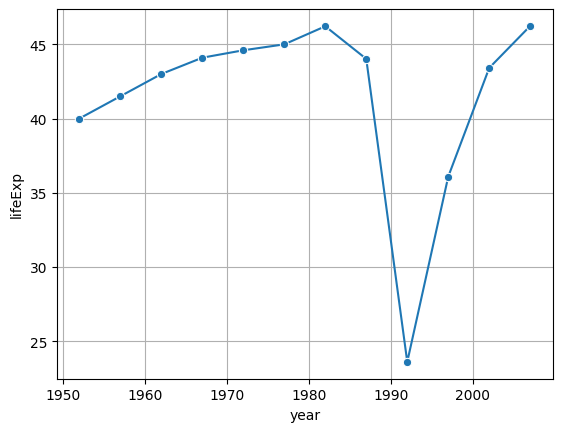

In [15]:
rwanda_df = gapminder[gapminder.country == "Rwanda"]

sns.lineplot(data=rwanda_df, x="year", y="lifeExp", marker="o")

plt.grid()
plt.show()

대륙별 연도별 기대수명

*   대륙별 기대수명 평균의 연도에 따른 변화.


In [29]:
gapminder.groupby(by=["continent", "year"]).lifeExp.mean()

continent  year
Africa     1952    39.135500
           1957    41.266346
           1962    43.319442
           1967    45.334538
           1972    47.450942
           1977    49.580423
           1982    51.592865
           1987    53.344788
           1992    53.629577
           1997    53.598269
           2002    53.325231
           2007    54.806038
Americas   1952    53.279840
           1957    55.960280
           1962    58.398760
           1967    60.410920
           1972    62.394920
           1977    64.391560
           1982    66.228840
           1987    68.090720
           1992    69.568360
           1997    71.150480
           2002    72.422040
           2007    73.608120
Asia       1952    46.314394
           1957    49.318544
           1962    51.563223
           1967    54.663640
           1972    57.319269
           1977    59.610556
           1982    62.617939
           1987    64.851182
           1992    66.537212
           1997    68.020515
           2002    69.233879
           2007    70.728485
Europe     1952    64.408500
           1957    66.703067
           1962    68.539233
           1967    69.737600
           1972    70.775033
           1977    71.937767
           1982    72.806400
           1987    73.642167
           1992    74.440100
           1997    75.505167
           2002    76.700600
           2007    77.648600
Oceania    1952    69.255000
           1957    70.295000
           1962    71.085000
           1967    71.310000
           1972    71.910000
           1977    72.855000
           1982    74.290000
           1987    75.320000
           1992    76.945000
           1997    78.190000
           2002    79.740000
           2007    80.719500
Name: lifeExp, dtype: float64

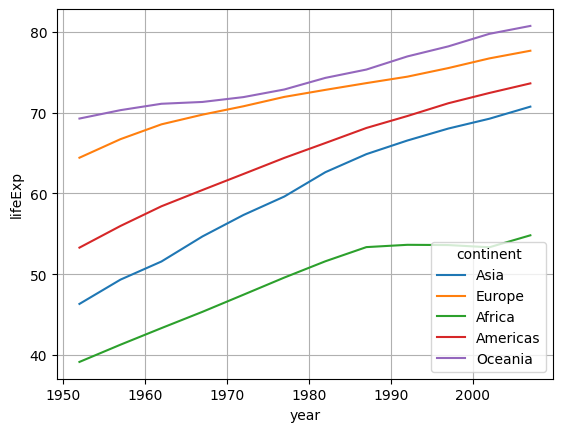

In [16]:
sns.lineplot(data=gapminder, x="year", y="lifeExp", hue="continent", errorbar=None)
#> esimator="mean" 생략가능
plt.grid()
plt.show()

# 1인당 GDP(gdpPercap) 분석

In [30]:
# 강사님 답안
gapminder.gdpPercap.max()  # 1인당 GDP 최대값

113523.1329

In [32]:
gapminder[gapminder.gdpPercap ==  gapminder.gdpPercap.max()]  # 1인당 GDP가 최대인 행

,country,continent,year,lifeExp,pop,gdpPercap
853,Kuwait,Asia,1957,58.033,212846,113523.1329


In [33]:
gapminder.gdpPercap.min()  # 1인당 GDP 최솟값

241.1658765

In [34]:
gapminder[gapminder.gdpPercap == gapminder.gdpPercap.min()]  # 1인당 GDP가 최소인 행

,country,continent,year,lifeExp,pop,gdpPercap
334,"Congo, Dem. Rep.",Africa,2002,44.966,55379852,241.165876


## 쿠웨이트의 1인당 GDP 변화

In [49]:
kuwait_df = gapminder[gapminder.country == "Kuwait"]

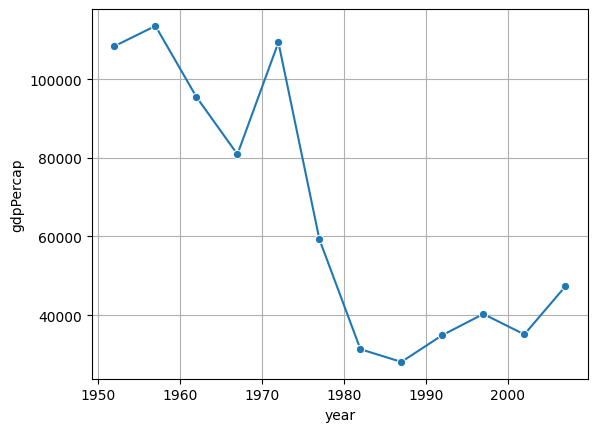

In [50]:
sns.lineplot(data=kuwait_df, x="year", y="gdpPercap", marker="o")

plt.grid()
plt.show()

## 콩고의 1인당 GDP 변화

In [51]:
congo_df = gapminder[gapminder.country == "Congo, Dem. Rep."]
congo_df

,country,continent,year,lifeExp,pop,gdpPercap
324,"Congo, Dem. Rep.",Africa,1952,39.143,14100005,780.542326
325,"Congo, Dem. Rep.",Africa,1957,40.652,15577932,905.860230
326,"Congo, Dem. Rep.",Africa,1962,42.122,17486434,896.314634
327,"Congo, Dem. Rep.",Africa,1967,44.056,19941073,861.593242
328,"Congo, Dem. Rep.",Africa,1972,45.989,23007669,904.896068
329,"Congo, Dem. Rep.",Africa,1977,47.804,26480870,795.757282
330,"Congo, Dem. Rep.",Africa,1982,47.784,30646495,673.747818
331,"Congo, Dem. Rep.",Africa,1987,47.412,35481645,672.774812
332,"Congo, Dem. Rep.",Africa,1992,45.548,41672143,457.719181
333,"Congo, Dem. Rep.",Africa,1997,42.587,47798986,312.188423


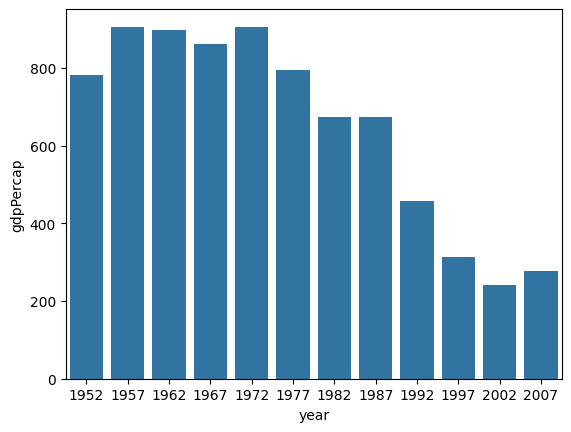

In [52]:
sns.barplot(data=congo_df, x="year", y="gdpPercap")

plt.show()

## 대륙별 1인당 GDP 평균의 연도별 변화

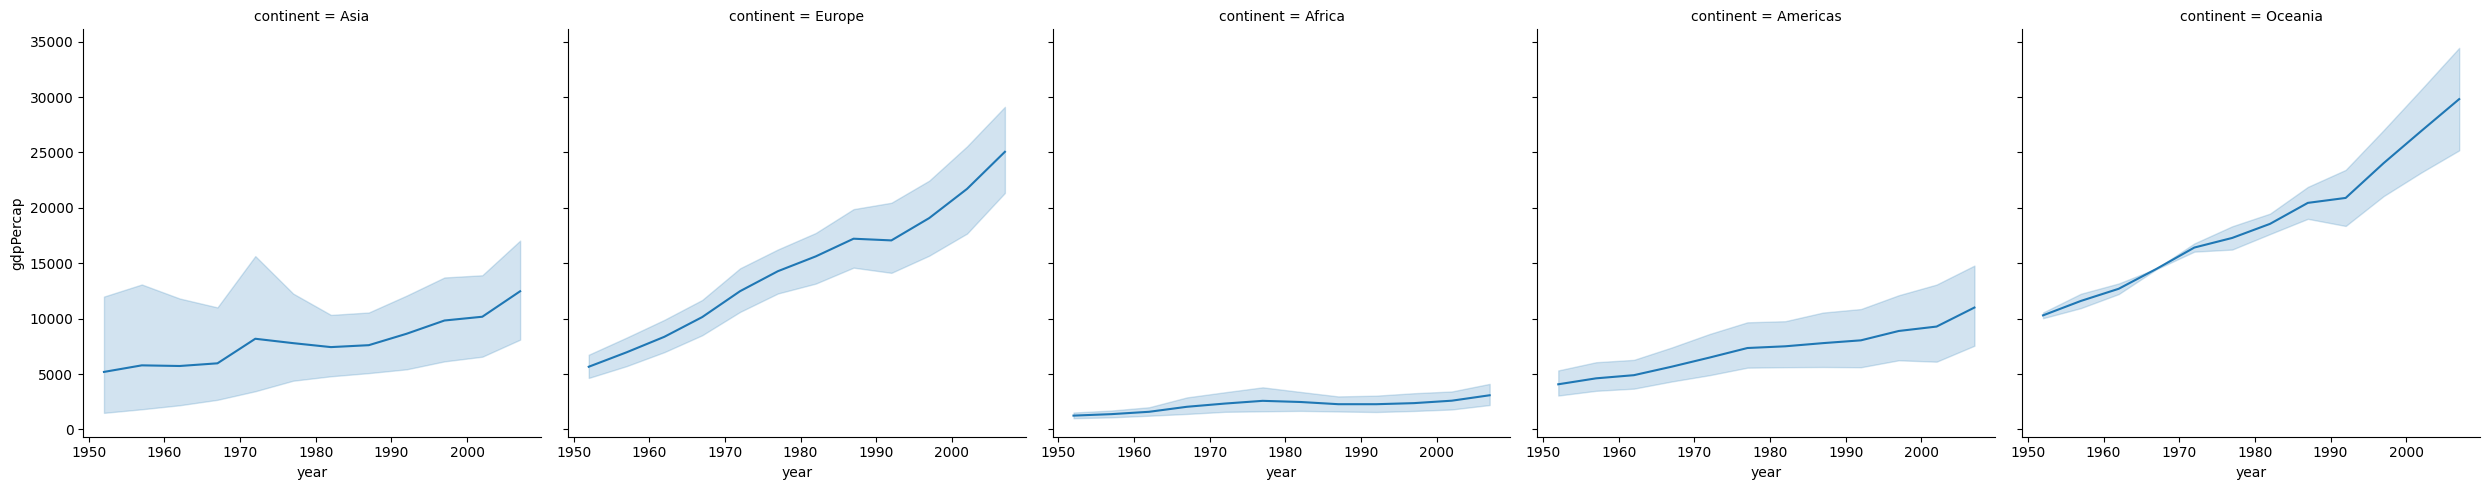

In [72]:
sns.relplot(data=gapminder, x="year", y="gdpPercap", kind="line", col="continent", estimator="mean")

plt.show()

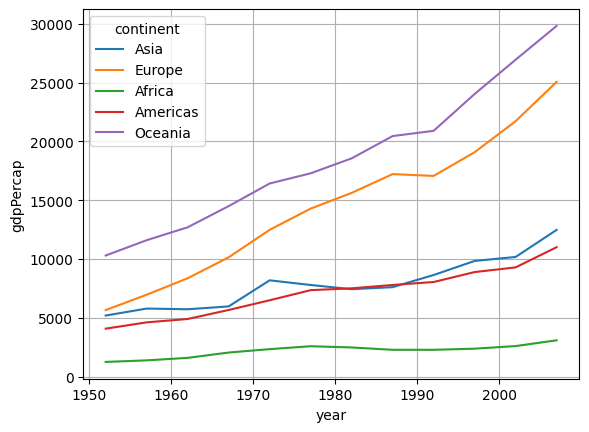

In [70]:
# 강사님 답안
sns.lineplot(data=gapminder, x="year", y="gdpPercap", hue="continent", errorbar=None)

plt.grid()
plt.show()

In [73]:
gapminder.groupby(["continent", "year"]).gdpPercap.mean()

continent  year
Africa     1952     1252.572466
           1957     1385.236062
           1962     1598.078825
           1967     2050.363801
           1972     2339.615674
           1977     2585.938508
           1982     2481.592960
           1987     2282.668991
           1992     2281.810333
           1997     2378.759555
           2002     2599.385159
           2007     3089.032605
Americas   1952     4079.062552
           1957     4616.043733
           1962     4901.541870
           1967     5668.253496
           1972     6491.334139
           1977     7352.007126
           1982     7506.737088
           1987     7793.400261
           1992     8044.934406
           1997     8889.300863
           2002     9287.677107
           2007    11003.031625
Asia       1952     5195.484004
           1957     5787.732940
           1962     5729.369625
           1967     5971.173374
           1972     8187.468699
           1977     7791.314020
           1982     7434.135157
           1987     7608.226508
           1992     8639.690248
           1997     9834.093295
           2002    10174.090397
           2007    12473.026870
Europe     1952     5661.057435
           1957     6963.012816
           1962     8365.486814
           1967    10143.823757
           1972    12479.575246
           1977    14283.979110
           1982    15617.896551
           1987    17214.310727
           1992    17061.568084
           1997    19076.781802
           2002    21711.732422
           2007    25054.481636
Oceania    1952    10298.085650
           1957    11598.522455
           1962    12696.452430
           1967    14495.021790
           1972    16417.333380
           1977    17283.957605
           1982    18554.709840
           1987    20448.040160
           1992    20894.045885
           1997    24024.175170
           2002    26938.778040
           2007    29810.188275
Name: gdpPercap, dtype: float64

## 2007년 1인당 GDP 상위 10개 국가

In [76]:
gapminder[gapminder.year == 2007].sort_values(by=["gdpPercap"], ascending=False).iloc[:10][["country", "gdpPercap"]].set_index(np.arange(1, 11))

# 강사님 답안
gdp_top10 = gapminder[gapminder.year == 2007].sort_values(by=["gdpPercap"], ascending=False).head(10)

gdp_top10

,country,continent,year,lifeExp,pop,gdpPercap
1151,Norway,Europe,2007,80.196,4627926,49357.19017
863,Kuwait,Asia,2007,77.588,2505559,47306.98978
1367,Singapore,Asia,2007,79.972,4553009,47143.17964
1619,United States,Americas,2007,78.242,301139947,42951.65309
755,Ireland,Europe,2007,78.885,4109086,40675.99635
671,"Hong Kong, China",Asia,2007,82.208,6980412,39724.97867
1487,Switzerland,Europe,2007,81.701,7554661,37506.41907
1091,Netherlands,Europe,2007,79.762,16570613,36797.93332
251,Canada,Americas,2007,80.653,33390141,36319.23501
695,Iceland,Europe,2007,81.757,301931,36180.78919


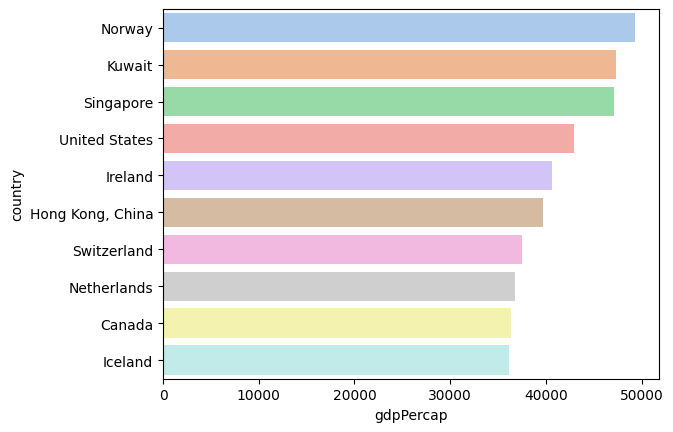

In [78]:
sns.barplot(data=gdp_top10, x="gdpPercap", y="country", hue="country", palette="pastel")

plt.show()

## 2007년 1인당 GDP 하위 10개 국가

In [79]:
gapminder[gapminder.year == 2007].sort_values(by=["gdpPercap"], ascending=True).iloc[:10][["country", "gdpPercap"]].set_index(np.arange(1, 11))

# 강사님 답안
gdp_bottom10 = gapminder[gapminder.year == 2007].sort_values(by="gdpPercap").head(n=10)

gdp_bottom10

,country,continent,year,lifeExp,pop,gdpPercap
335,"Congo, Dem. Rep.",Africa,2007,46.462,64606759,277.551859
899,Liberia,Africa,2007,45.678,3193942,414.507341
215,Burundi,Africa,2007,49.580,8390505,430.070692
1703,Zimbabwe,Africa,2007,43.487,12311143,469.709298
635,Guinea-Bissau,Africa,2007,46.388,1472041,579.231743
1127,Niger,Africa,2007,56.867,12894865,619.676892
503,Eritrea,Africa,2007,58.040,4906585,641.369524
515,Ethiopia,Africa,2007,52.947,76511887,690.805576
263,Central African Republic,Africa,2007,44.741,4369038,706.016537
563,Gambia,Africa,2007,59.448,1688359,752.749726


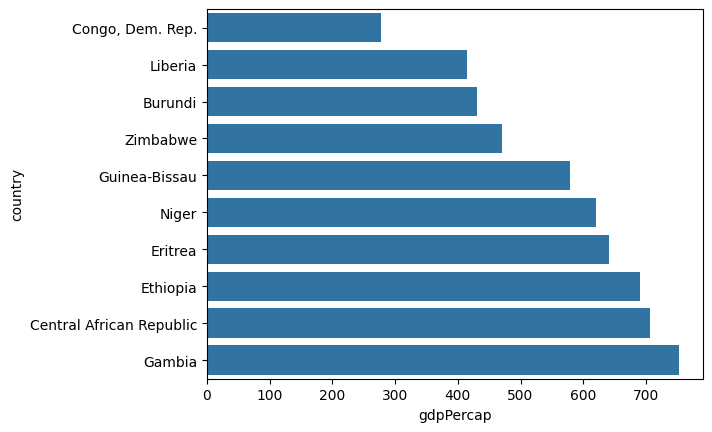

In [80]:
sns.barplot(data=gdp_bottom10, x="gdpPercap", y="country")
plt.show()

## 한국, 중국, 일본의 1인당 GDP 변화

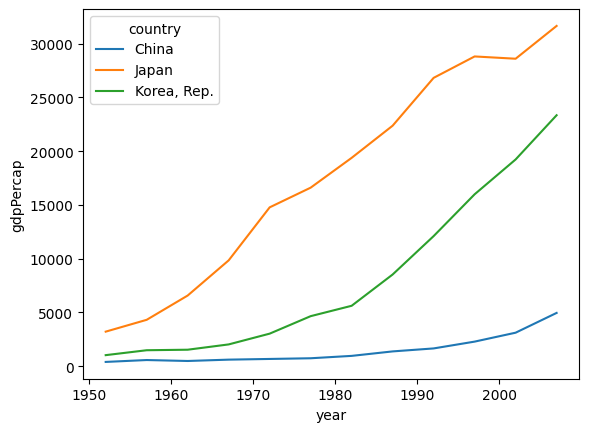

In [91]:
kcj_gdp = gapminder[gapminder.country.isin(["Korea, Rep.", "Japan", "China"])]
# str.contains("kor|japan|china", case=False)

sns.lineplot(data=kcj_gdp, x="year", y="gdpPercap", hue="country")

plt.show()

In [95]:
# 강사님 답안
cjk = ["China", "Japan", "Korea, Rep."]
# cjk_df = gapminder[(gapminder.country == "China") | (gapminder.country == "Japan") | (gapminder.country == "Korea, Rep.")]

cjk_df = gapminder[gapminder.country.isin(cjk)]
cjk_df

,country,continent,year,lifeExp,pop,gdpPercap
288,China,Asia,1952,44.00000,556263527,400.448611
289,China,Asia,1957,50.54896,637408000,575.987001
290,China,Asia,1962,44.50136,665770000,487.674018
291,China,Asia,1967,58.38112,754550000,612.705693
292,China,Asia,1972,63.11888,862030000,676.900092
293,China,Asia,1977,63.96736,943455000,741.237470
294,China,Asia,1982,65.52500,1000281000,962.421381
295,China,Asia,1987,67.27400,1084035000,1378.904018
296,China,Asia,1992,68.69000,1164970000,1655.784158
297,China,Asia,1997,70.42600,1230075000,2289.234136


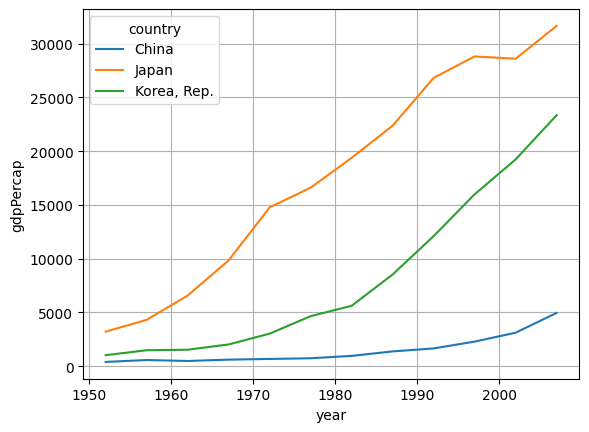

In [96]:
#
sns.lineplot(data=cjk_df, x="year", y="gdpPercap", hue="country")
plt.grid()
plt.show()

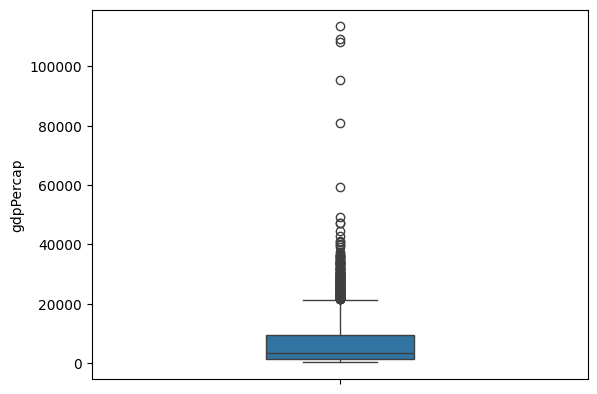

In [17]:
# 1인당 GDP 분석
sns.boxplot(data=gapminder, y="gdpPercap", width=0.3, fill=True)

plt.show()

In [18]:
# 1인당 gdp 최댓값 행
gapminder[gapminder.gdpPercap == gapminder.gdpPercap.max()]

,country,continent,year,lifeExp,pop,gdpPercap
853,Kuwait,Asia,1957,58.033,212846,113523.1329


In [19]:
# 1인당 gdp 최솟값 행
gapminder[gapminder.gdpPercap == gapminder.gdpPercap.min()]

,country,continent,year,lifeExp,pop,gdpPercap
334,"Congo, Dem. Rep.",Africa,2002,44.966,55379852,241.165876


## 인구 분석

In [100]:
gapminder[gapminder["pop"] == gapminder["pop"].max()]  # 인구가 최대인 행

,country,continent,year,lifeExp,pop,gdpPercap
299,China,Asia,2007,72.961,1318683096,4959.114854


In [101]:
gapminder[gapminder["pop"] == gapminder["pop"].min()]  # 인구가 최소인 행

,country,continent,year,lifeExp,pop,gdpPercap
1296,Sao Tome and Principe,Africa,1952,46.471,60011,879.583586


### 대륙별 인구 변화

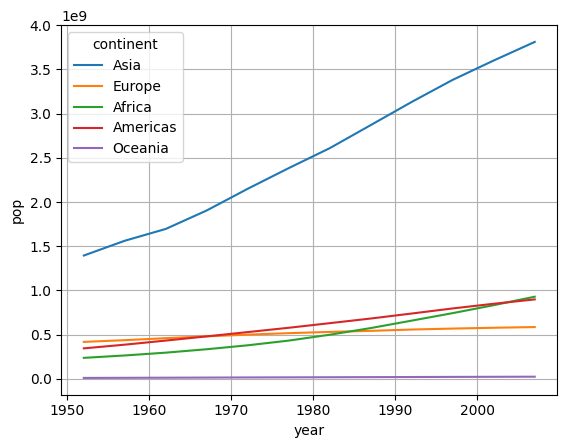

In [107]:
sns.lineplot(data=gapminder, x="year", y="pop", hue="continent", errorbar=None, estimator="sum")
plt.grid()
plt.show()

In [108]:
gapminder.groupby(by=["continent", "year"])["pop"].sum()

continent  year
Africa     1952     237640501
           1957     264837738
           1962     296516865
           1967     335289489
           1972     379879541
           1977     433061021
           1982     499348587
           1987     574834110
           1992     659081517
           1997     743832984
           2002     833723916
           2007     929539692
Americas   1952     345152446
           1957     386953916
           1962     433270254
           1967     480746623
           1972     529384210
           1977     578067699
           1982     630290920
           1987     682753971
           1992     739274104
           1997     796900410
           2002     849772762
           2007     898871184
Asia       1952    1395357351
           1957    1562780599
           1962    1696357182
           1967    1905662900
           1972    2150972248
           1977    2384513556
           1982    2610135582
           1987    2871220762
           1992    3133292191
           1997    3383285500
           2002    3601802203
           2007    3811953827
Europe     1952     418120846
           1957     437890351
           1962     460355155
           1967     481178958
           1972     500635059
           1977     517164531
           1982     531266901
           1987     543094160
           1992     558142797
           1997     568944148
           2002     578223869
           2007     586098529
Oceania    1952      10686006
           1957      11941976
           1962      13283518
           1967      14600414
           1972      16106100
           1977      17239000
           1982      18394850
           1987      19574415
           1992      20919651
           1997      22241430
           2002      23454829
           2007      24549947
Name: pop, dtype: int64

### 아시아 대륙을 제외한 4개 대륙의 인구 변화

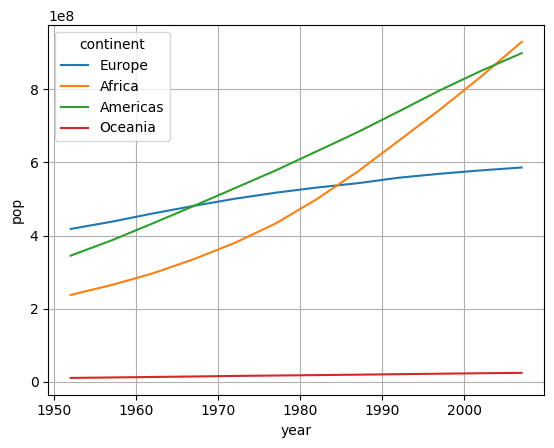

In [115]:
sns.lineplot(data=gapminder[gapminder.continent != "Asia"], x="year", y="pop", estimator="sum", hue="continent", errorbar=None)

plt.grid()
plt.show()

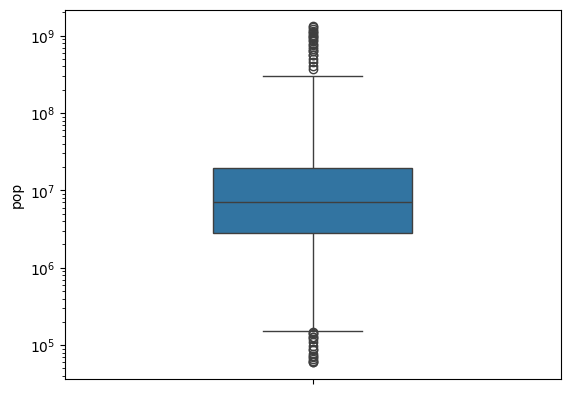

In [20]:
# 인구 수 분석
sns.boxplot(data=gapminder, y="pop", log_scale=True, width=0.4)

plt.show()

## 상관관계

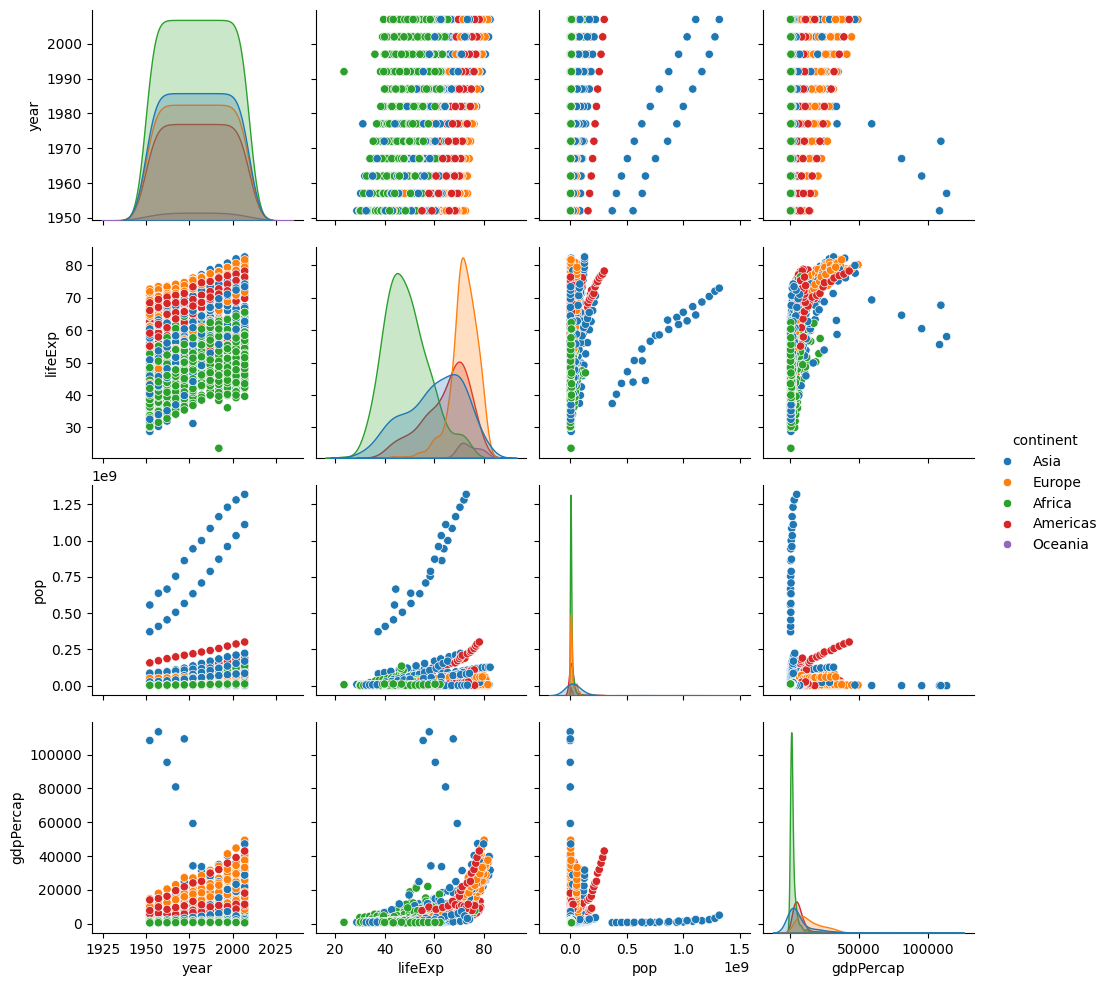

In [120]:
sns.pairplot(data=gapminder, hue="continent")

plt.show()

In [122]:
gapminder[["year", "lifeExp", "pop", "gdpPercap"]].corr()

,year,lifeExp,pop,gdpPercap
year,1.000000,0.435611,0.082308,0.227318
lifeExp,0.435611,1.000000,0.064955,0.583706
pop,0.082308,0.064955,1.000000,-0.025600
gdpPercap,0.227318,0.583706,-0.025600,1.000000


### 2007년도 변수들 간의 상관관계

In [123]:
df_2007 = gapminder[gapminder.year == 2007]
df_2007

,country,continent,year,lifeExp,pop,gdpPercap
11,Afghanistan,Asia,2007,43.828,31889923,974.580338
23,Albania,Europe,2007,76.423,3600523,5937.029526
35,Algeria,Africa,2007,72.301,33333216,6223.367465
47,Angola,Africa,2007,42.731,12420476,4797.231267
59,Argentina,Americas,2007,75.320,40301927,12779.379640
...,...,...,...,...,...,...
1655,Vietnam,Asia,2007,74.249,85262356,2441.576404
1667,West Bank and Gaza,Asia,2007,73.422,4018332,3025.349798
1679,"Yemen, Rep.",Asia,2007,62.698,22211743,2280.769906
1691,Zambia,Africa,2007,42.384,11746035,1271.211593


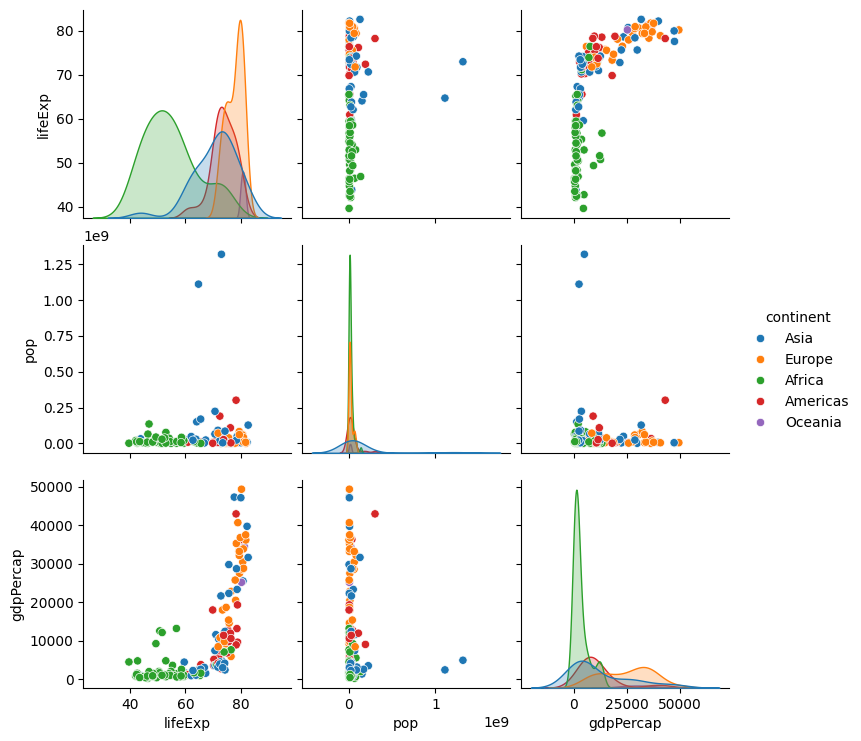

In [125]:
sns.pairplot(data=df_2007, vars=["lifeExp", "pop", "gdpPercap"], hue="continent")

plt.show()

In [127]:
df_2007[["lifeExp", "pop", "gdpPercap"]].corr("kendall")

,lifeExp,pop,gdpPercap
lifeExp,1.000000,0.008091,0.677954
pop,0.008091,1.000000,-0.037059
gdpPercap,0.677954,-0.037059,1.000000


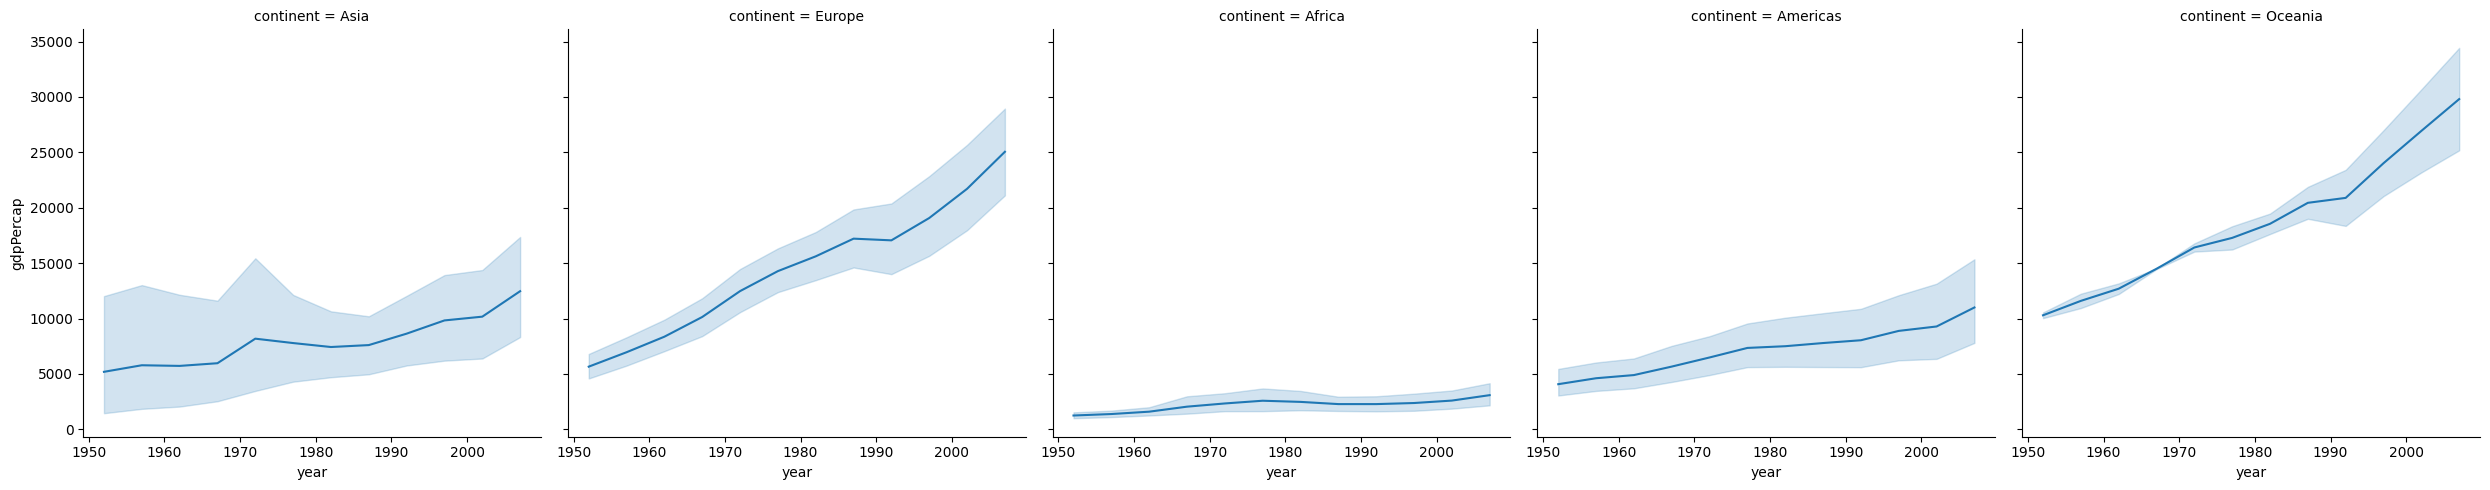

In [21]:
# 그룹별 통계량 및 자유 분석

sns.relplot(data=gapminder, x="year", y="gdpPercap", col="continent", kind="line", estimator="mean")

plt.show()

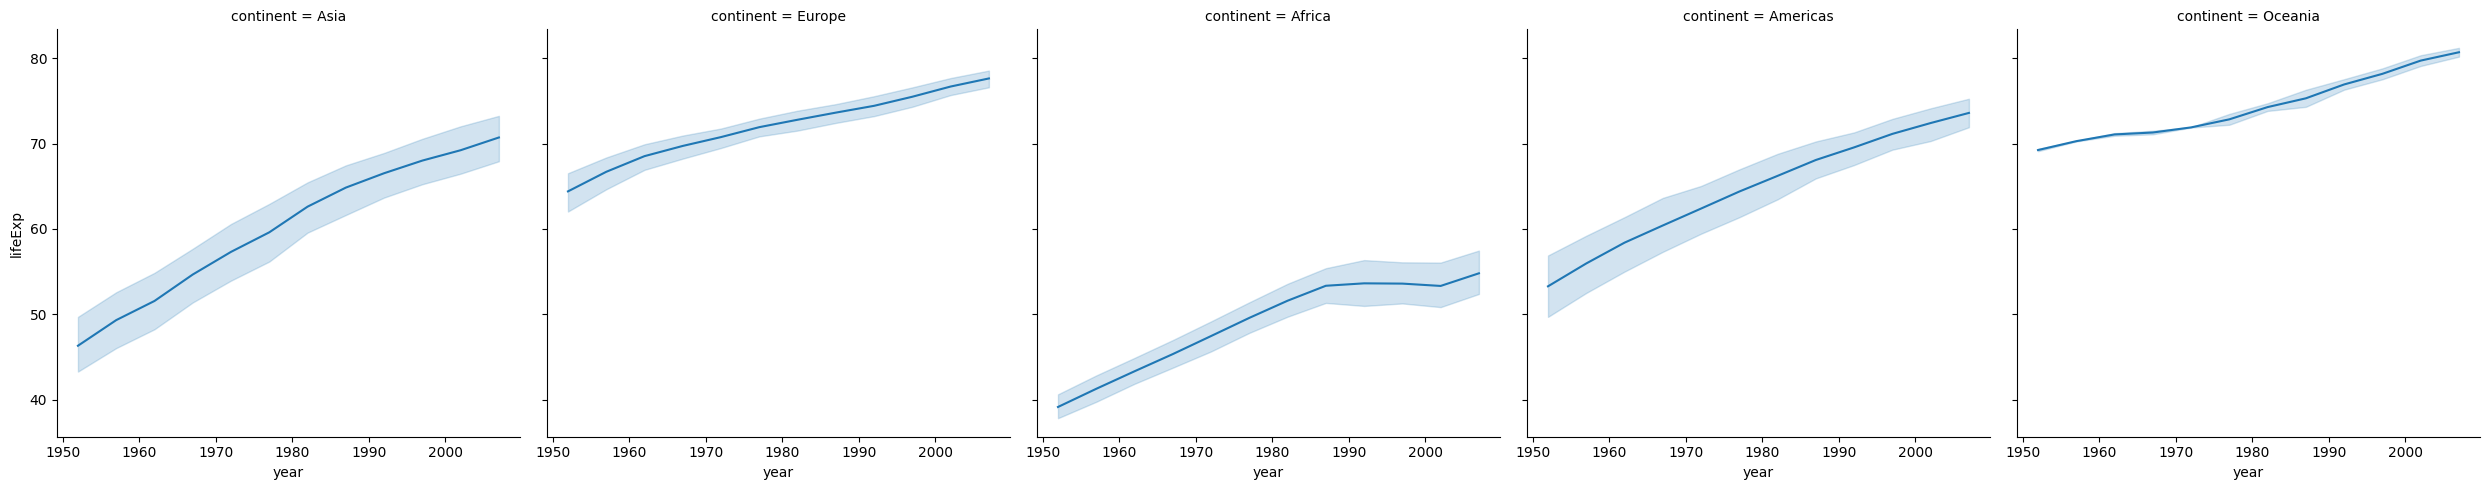

In [22]:
sns.relplot(data=gapminder, x="year", y="lifeExp", col="continent", kind="line", estimator="mean")

plt.show()

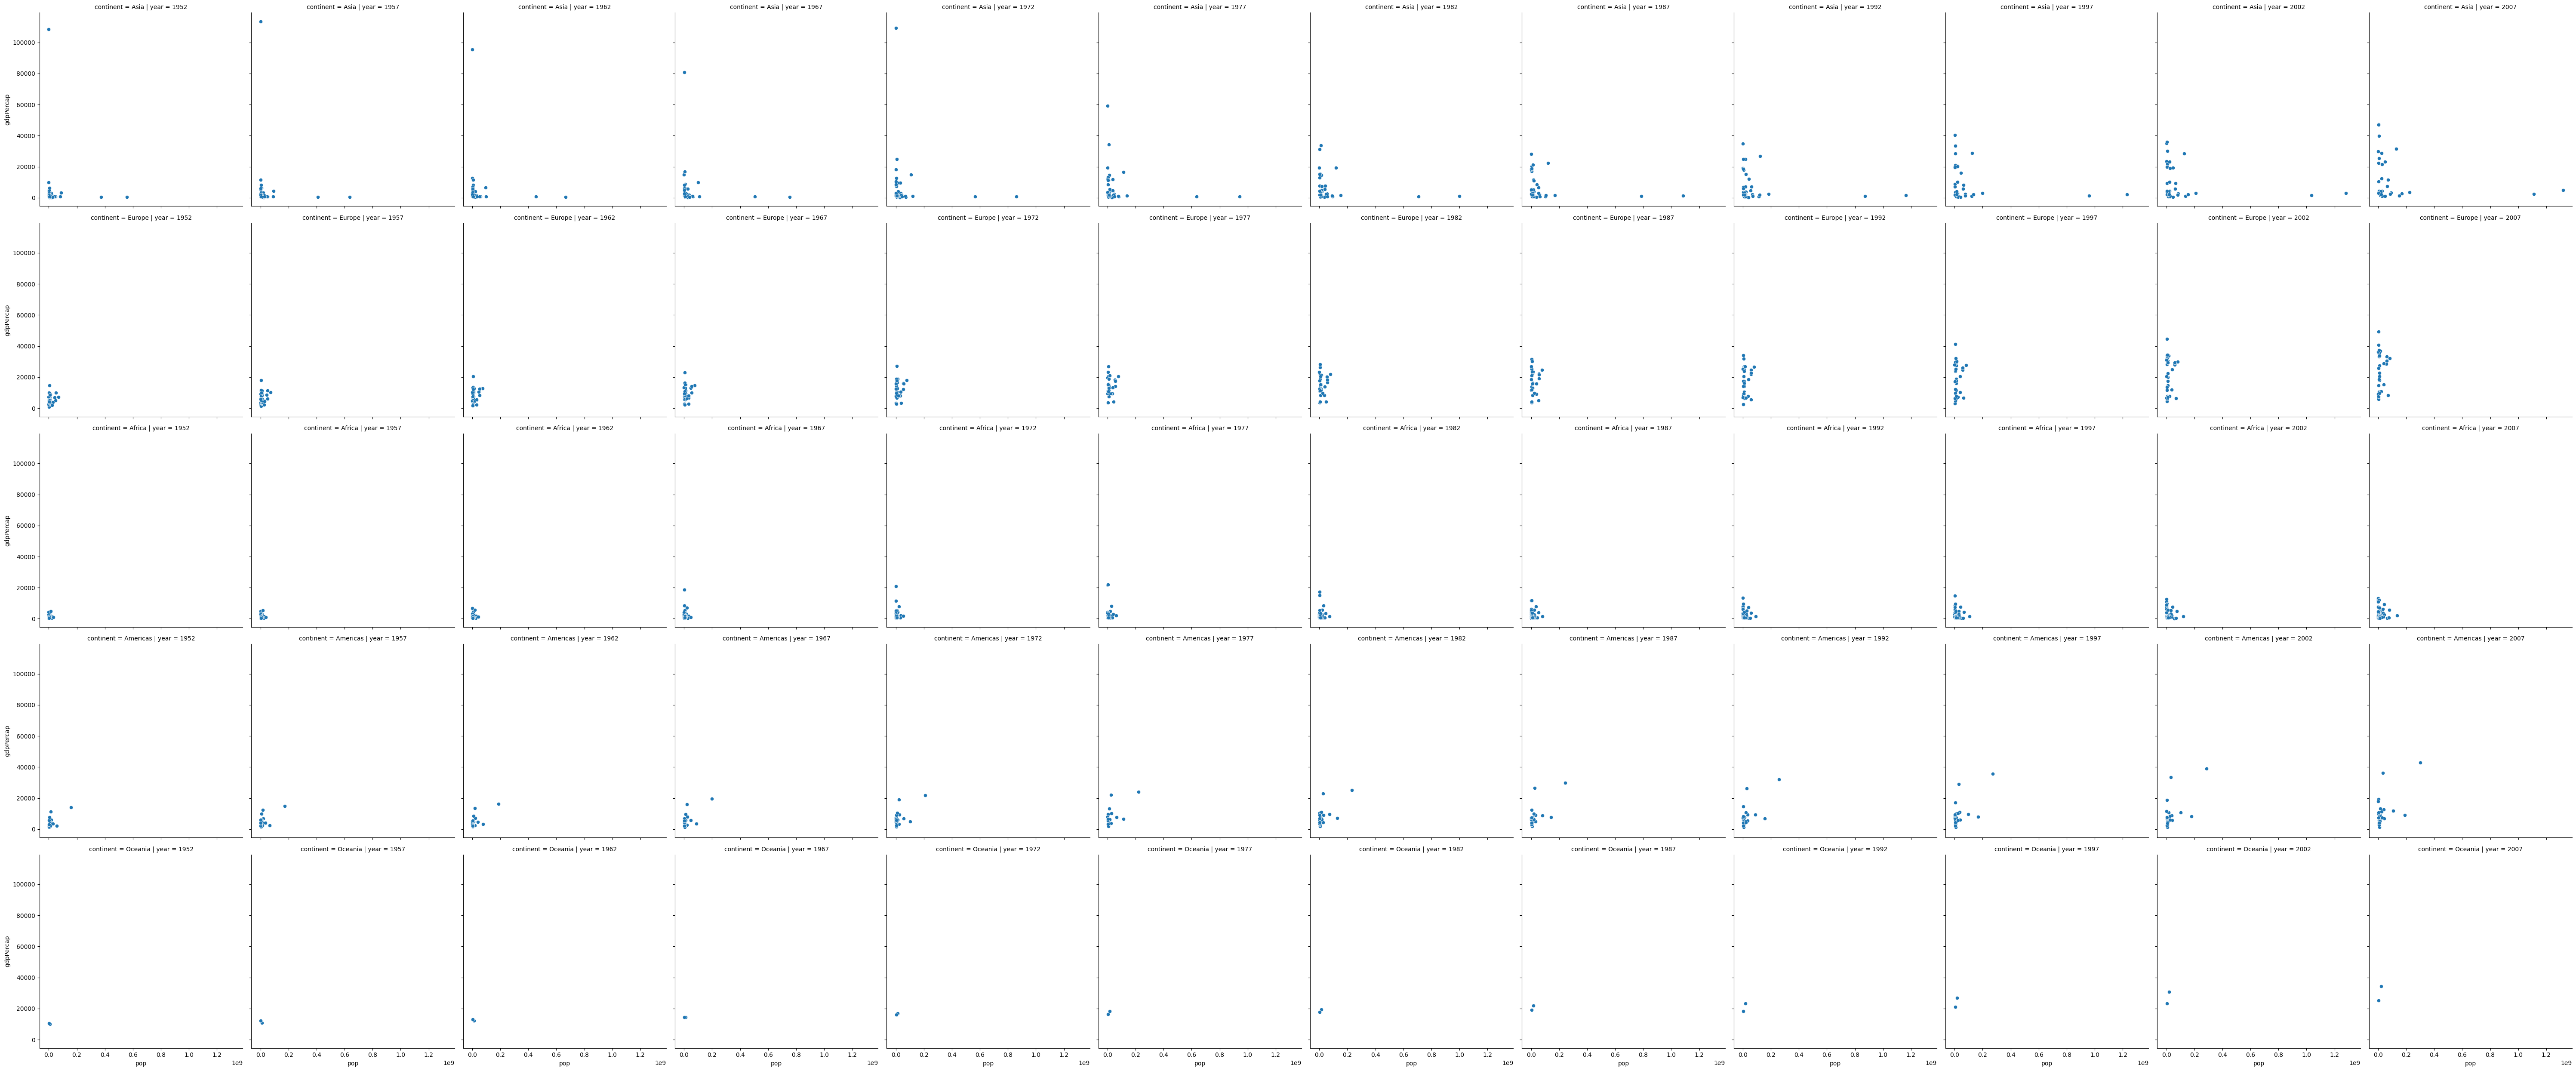

In [23]:
sns.relplot(data=gapminder, x="pop", y="gdpPercap", row="continent", col="year")

plt.show()

In [24]:
# 1. 계산 함수 정의
def calculate_spread_stats(group):
    # 인구와 GDP 데이터 추출
    data = group[['pop', 'gdpPercap']]

    # 공분산 행렬 계산
    cov_matrix = data.cov()

    # 공분산 값 (pop과 gdpPercap 사이의 관계)
    covariance = cov_matrix.iloc[0, 1]

    # 일반화 분산 (행렬식: 데이터가 차지하는 면적의 지표)
    # np.linalg.det는 행렬의 크기(퍼짐 정도)를 하나의 숫자로 변환합니다.
    determinant = np.linalg.det(cov_matrix)

    return pd.Series({
        'Covariance': covariance,
        'Spread_Area(Det)': determinant
    })

# 2. 대륙별, 연도별로 그룹화하여 계산
results = gapminder.groupby(['continent', 'year']).apply(calculate_spread_stats, include_groups=False)

# 3. 결과 확인
print(results.reset_index())

   continent  year    Covariance  Spread_Area(Det)
0     Africa  1952  2.732818e+08      3.848632e+19
1     Africa  1957  3.100987e+08      6.434994e+19
2     Africa  1962 -3.341906e+08      1.352069e+20
3     Africa  1967 -1.811328e+09      6.514741e+20
4     Africa  1972 -2.059128e+09      1.104555e+21
5     Africa  1977 -2.896754e+09      2.294692e+21
6     Africa  1982 -1.825080e+09      1.900565e+21
7     Africa  1987 -1.148593e+09      1.536117e+21
8     Africa  1992 -2.716396e+09      2.149031e+21
9     Africa  1997 -4.082251e+09      3.125652e+21
10    Africa  2002 -6.497784e+09      4.353341e+21
11    Africa  2007 -9.625348e+09      8.035530e+21
12  Americas  1952  6.398235e+10      5.330933e+21
13  Americas  1957  7.225960e+10      8.634732e+21
14  Americas  1962  8.771394e+10      1.000230e+22
15  Americas  1967  1.134039e+11      1.757151e+22
16  Americas  1972  1.361487e+11      2.710615e+22
17  Americas  1977  1.605074e+11      4.005790e+22
18  Americas  1982  1.813092e+1

In [25]:
gapminder.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106
